In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

(np.float64(-2.4941731776918745),
 np.float64(2.6712485206537995),
 np.float64(-2.7209603171021537),
 np.float64(2.704845482126591))

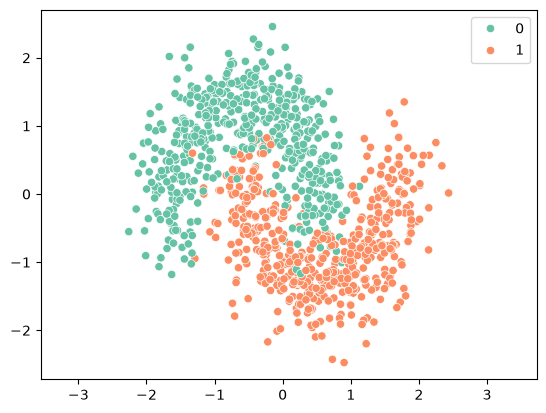

In [2]:
from sklearn.datasets import make_classification, make_blobs, make_moons

X,y = make_moons(n_samples=1000, noise=0.24, random_state=42)
# scale X to be around 0
X = (X - X.mean(axis=0)) / X.std(axis=0)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set2')
plt.axis('equal')

In [3]:
# train a mlp
from sklearn.neural_network import MLPClassifier
#clf.fit(X,y)

In [ ]:
# plot the decision boundary
clf = MLPClassifier(hidden_layer_sizes=(16,16), max_iter=10, random_state=42,warm_start=True)
def plot_decision_boundary(X, y, margin=0.05, confidence=False,ax=None,epoch=None):
    # create a mesh grid
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # predict on the mesh grid
    if confidence:
        Z = np.max(clf.predict_proba(np.c_[xx.ravel(), yy.ravel()]), axis=1)
        cmap = plt.cm.YlGnBu

    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        cmap = plt.cm.coolwarm
    Z = Z.reshape(xx.shape)

    # plot the contour and training examples
    if ax is None:
        ax = plt.gca()
    if confidence:
        levels = np.linspace(0.5, 1, 21)
        cs = ax.contourf(xx, yy, Z, levels=levels, alpha=0.8, cmap=cmap, vmin=0.5, vmax=1)
        cbar = plt.colorbar(cs, ax=ax)

        cbar.set_label('Confidence')
    else:
        ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap)
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, 
                    palette='Set2', edgecolor='k', 
                    alpha=0.8, s=20,
                    ax=ax)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    plt.axis('equal')
    for spline in ax.spines.values():
        spline.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    # change the labels as 'Class 0' and 'Class 1'
    ax.legend(loc='upper left',ncol=2,# title='Class', 
              labels=['Class 0', 'Class 1'])

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if epoch is not None:
        ax.set_title(f'Decision Boundary at Epoch {epoch}')
        plt.savefig(f'figures//decision_boundary_{epoch:03d}.png', dpi=300)
    else:
        plt.show()
    plt.close()
for epoch in range(0, 20):
    clf.fit(X,y)
    plot_decision_boundary(X, y,margin=0.4,confidence=True, epoch=epoch)

In [22]:
# now we can create the animation and remove the images.
# the gif should not loop, but should end on the last one
REMOVE_IMAGES = False
import os
os.makedirs('figures', exist_ok=True)
figures = os.listdir('figures')
figures = [f for f in figures if (f.endswith('.png')) and
            ('decision_boundary' in f)]
figures

['decision_boundary_000.png',
 'decision_boundary_001.png',
 'decision_boundary_002.png',
 'decision_boundary_003.png',
 'decision_boundary_004.png',
 'decision_boundary_005.png',
 'decision_boundary_006.png',
 'decision_boundary_007.png',
 'decision_boundary_008.png',
 'decision_boundary_009.png',
 'decision_boundary_010.png',
 'decision_boundary_011.png',
 'decision_boundary_012.png',
 'decision_boundary_013.png',
 'decision_boundary_014.png',
 'decision_boundary_015.png',
 'decision_boundary_016.png',
 'decision_boundary_017.png',
 'decision_boundary_018.png',
 'decision_boundary_019.png']

In [ ]:
import imageio


# Create the animation
images = []
for filename in figures:
    images.append(imageio.imread(f'figures/{filename}'))

# make the animation longer by increasing per-frame duration and holding last frame
# NOTE: imageio's GIF writer expects duration in milliseconds, not seconds
durations = [50] * len(images)  # ms per frame
durations[-1] = 3000             # hold last frame for 3 seconds
imageio.mimsave('figures/decision_boundary.gif', images, duration=durations, loop=0)

# Remove the individual image files
if REMOVE_IMAGES:
    for filename in figures:
        os.remove(f'figures/{filename}')

In [7]:
# now we take the last image and change a bit the animation:
# take a random sample 
# than take its closest point predicted with the opposite class
# use 25 frames to create a smooth transition between a circle with increasing radius that is centered on the point and it grows till the circle reaches the closest point of the opposite class.
# The circle should be filled with a transparent color and the point should be highlighted with a different color. The animation should end with the point being highlighted, the circle disappearing and their distance being displayed on the screen with a black line

# take the sample with the smaller feature 2
sample_index = np.argmin(X[:, 1])

def plot_decision_boundary_sample_and_radius(X, y, margin=0.05, confidence=False,ax=None,epoch=None,
                                             sample_index=None, closest_index=None,
                                             radius=None, highlight_point=False,
                                             draw_line=False):
    # create a mesh grid
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # predict on the mesh grid
    if confidence:
        Z = np.max(clf.predict_proba(np.c_[xx.ravel(), yy.ravel()]), axis=1)
        cmap = plt.cm.YlGnBu

    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        cmap = plt.cm.coolwarm
    Z = Z.reshape(xx.shape)

    # plot the contour and training examples
    if ax is None:
        ax = plt.gca()
    if confidence:
        levels = np.linspace(0.5, 1, 11)
        cs = ax.contourf(xx, yy, Z, levels=levels, alpha=0.7, cmap=cmap, vmin=0.5, vmax=1)
        cbar = plt.colorbar(cs, ax=ax)

        cbar.set_label('Confidence')
    else:
        ax.contourf(xx, yy, Z, alpha=0.7, cmap=cmap)
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, 
                    palette='Set2', edgecolor='k', 
                    alpha=0.7, s=20,
                    ax=ax)

    # draw the circle with the given radius and center at sample_index
    if sample_index is not None:
        if highlight_point:
            ax.scatter(X[sample_index, 0], X[sample_index, 1], color='black', s=100, edgecolor='k')
        
        circle = plt.Circle((X[sample_index, 0], X[sample_index, 1]), radius, color='black', alpha=(0.7 if not draw_line else 0.3),
                                ls='--', lw=2, fill=False)
        ax.add_artist(circle)
        if draw_line and closest_index is not None:
            ax.plot([X[sample_index, 0], X[closest_index, 0]], [X[sample_index, 1], X[closest_index, 1]], color='black', lw=2, ls='-')

    all_min = np.max([X[:, 0].min(), X[:, 1].min()])
    all_max = np.min([X[:, 0].max(), X[:, 1].max()])
    ax.set_xlim(all_min, all_max)
    ax.set_ylim(all_min, all_max)
    plt.axis('equal')
    for spline in ax.spines.values():
        spline.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    # change the labels as 'Class 0' and 'Class 1'
    ax.legend(loc='upper left',ncol=2,# title='Class', 
              labels=['Class 0', 'Class 1'])

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if epoch is not None:
        ax.set_title(f'GrowingSpheres example')
        plt.savefig(f'figures//Growing_Circle_{epoch:03d}.png', dpi=300)
    else:
        plt.show()
    plt.close()
y_pred = clf.predict(X)
# take the indices of the points that are correclty predicted as the opposite class of the sample_index
# take the indices predicted as the opposite class of the sample_index
opposite_indices = np.where(y_pred != y[sample_index])[0]
# take the closest point to the sample_index among the opposite_indices
closest_index = opposite_indices[np.argmin(np.linalg.norm(X[opposite_indices] - X[sample_index], axis=1))]
# take the radius as the distance between the sample_index and the closest_index
radius = np.linalg.norm(X[closest_index] - X[sample_index])

In [8]:

print(radius)
r = radius
frames = 25
draw_line = False
for i_f, r in enumerate(list(np.linspace(0, radius, frames))):
    if i_f == frames-1:
        draw_line = True
    plot_decision_boundary_sample_and_radius(X, y, 
                                             margin=0.4, confidence=True, epoch=i_f,
                                             sample_index=sample_index, closest_index=closest_index,radius=r,
                                             highlight_point=True,
                                             draw_line=draw_line)
    

1.9189357483248812


In [ ]:
# now create the gif 
# Create the animation
images = []
REMOVE_IMAGES = False
figures = os.listdir('figures')

figures = [f for f in figures if (f.endswith('.png')) and
            ('Growing_Circle' in f)]
# repeat the last one 10 times to make the animation pause on the last frame
figures += [figures[-1]]*10
for filename in figures:
    images.append(imageio.imread(f'figures/{filename}'))

# NOTE: imageio's GIF writer expects duration in milliseconds, not seconds
durations = [150] * len(images)
durations[-1] = 3000  # hold the last frame for 3 seconds

imageio.mimsave('figures/Growing_Circle.gif', 
                images, duration=durations, loop=0)
# Remove the individual image files
if REMOVE_IMAGES:
    for filename in figures:
        os.remove(f'figures/{filename}')